In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
import os

In [4]:
df=pd.read_csv("../../data/raw/raw.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  str    
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  str    
 4   vehicle_number                298450 non-null  str    
 5   vehicle_type                  298450 non-null  str    
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  str    
 8   offence_code                  298450 non-null  str    
 9   created_datetime              298450 non-null  str    
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  str    
 12  device_id                     298450 non-null  str    


In [6]:
df.drop(columns=['description','action_taken_timestamp','closed_datetime'],inplace=True)

In [7]:
df['created_datetime'] = pd.to_datetime(df['created_datetime'], errors='coerce')
df['modified_datetime'] = pd.to_datetime(df['modified_datetime'], errors='coerce')

In [8]:
df = df.dropna(subset=['created_datetime','modified_datetime'])

In [9]:
len(df)

298445

In [10]:
df['created_datetime'] = df['created_datetime'].dt.tz_convert('Asia/Kolkata')
df['modified_datetime'] = df['modified_datetime'].dt.tz_convert('Asia/Kolkata')

In [11]:
df['cdt_minute of day'] = (df['created_datetime'].dt.hour * 60) + df['created_datetime'].dt.minute
df['cdt_hour'] = df['created_datetime'].dt.hour
df['cdt_day_of_week'] = df['created_datetime'].dt.day_name()
df['cdt_month'] = df['created_datetime'].dt.month
df['cdt_date'] = df['created_datetime'].dt.date

In [12]:
df['mdt_minute of day'] = (df['modified_datetime'].dt.hour * 60) + df['modified_datetime'].dt.minute
df['mdt_hour'] = df['modified_datetime'].dt.hour
df['mdt_day_of_week'] = df['modified_datetime'].dt.day_name()
df['mdt_month'] = df['modified_datetime'].dt.month
df['mdt_date'] = df['modified_datetime'].dt.date

In [13]:
df['processing_duration_minutes'] = (df['modified_datetime'] - df['created_datetime']).dt.total_seconds() / 60

In [14]:
df.sample(5)

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,...,cdt_hour,cdt_day_of_week,cdt_month,cdt_date,mdt_minute of day,mdt_hour,mdt_day_of_week,mdt_month,mdt_date,processing_duration_minutes
63142,FKID063142,13.030656,77.536895,"Mumbai Bengaluru Highway, Gorguntepalya Juncti...",FKN00GL55504,LGV,"[""WRONG PARKING""]",[112],2024-02-23 05:37:46+05:30,2024-02-23 05:38:24.526134+05:30,...,5,Friday,2,2024-02-23,338,5,Friday,2,2024-02-23,0.642102
108461,FKID108461,12.961158,77.561638,"Sirsi Road, Sirsi Circle, Chamarajpet, Bengalu...",FKN00GL91487,SCOOTER,"[""NO PARKING""]",[113],2024-03-17 03:28:46+05:30,2024-03-17 03:46:54.880636+05:30,...,3,Sunday,3,2024-03-17,226,3,Sunday,3,2024-03-17,18.148011
271109,FKID271109,12.991842,77.590258,"14th Main Road, Valliappa Nagar, Bengaluru, Ka...",FKN00GL121424,SCOOTER,"[""NO PARKING""]",[113],2024-01-25 05:08:46+05:30,2024-01-25 05:15:21.376624+05:30,...,5,Thursday,1,2024-01-25,315,5,Thursday,1,2024-01-25,6.589610
245607,FKID245607,12.998091,77.552516,"Padmabhushan Dr MC Modi Road, Navarang Circle,...",FKN00GL196604,SCOOTER,"[""WRONG PARKING""]",[112],2024-01-15 05:20:46+05:30,2024-01-15 06:40:25.757105+05:30,...,5,Monday,1,2024-01-15,400,6,Monday,1,2024-01-15,79.662618
291644,FKID291644,12.975222,77.588512,"Cubbon Park Road, Gandhi Nagar 2, Gandhi Nagar...",FKN00GL228451,CAR,"[""NO PARKING""]",[113],2023-11-20 06:55:46+05:30,2023-11-20 06:59:45.582574+05:30,...,6,Monday,11,2023-11-20,419,6,Monday,11,2023-11-20,3.993043


<Axes: ylabel='processing_duration_minutes'>

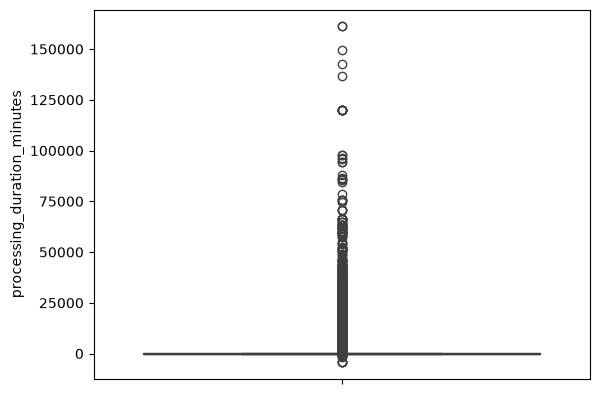

In [15]:
sns.boxplot(df['processing_duration_minutes'])

In [16]:
df['processing_duration_minutes'].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99])

count    298445.000000
mean        510.881835
std        2463.155945
min       -4318.555995
1%            0.604041
25%           4.938974
50%          15.896755
75%          71.166056
95%        2688.044205
99%        9367.570118
max      161183.000694
Name: processing_duration_minutes, dtype: float64

In [17]:
OUT_DIR = "../../data"

PARKING_TYPES = {
    "NO PARKING", "WRONG PARKING", "DOUBLE PARKING", "PARKING IN A MAIN ROAD",
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC", "PARKING NEAR ROAD CROSSING",
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS", "PARKING ON FOOTPATH",
    "PARKING OPPOSITE TO ANOTHER PARKED VEHICLE", "PARKING OTHER THAN BUS STOP",
}

VEHICLE_FOOTPRINT_WEIGHT = {
    "SCOOTER": 1.0, "MOTOR CYCLE": 1.0, "MOPED": 1.0,
    "CAR": 2.5, "JEEP": 2.5, "VAN": 2.5, "PASSENGER AUTO": 2.0,
    "GOODS AUTO": 2.0, "TEMPO": 3.0, "LGV": 3.5, "MAXI-CAB": 3.0,
    "PRIVATE BUS": 5.0, "BUS (BMTC/KSRTC)": 5.0, "TOURIST BUS": 5.0,
    "FACTORY BUS": 5.0, "SCHOOL VEHICLE": 5.0, "HGV": 5.5, 
    "LORRY/GOODS VEHICLE": 5.5, "MINI LORRY": 4.0, "TRACTOR": 4.0, 
    "TANKER": 5.5, "OTHERS": 2.0,
}

In [18]:
def clean_pipeline(dataframe: pd.DataFrame):
    df = dataframe.copy()
    
    # 1. Parse Datetimes
    df["created_datetime"] = pd.to_datetime(df["created_datetime"], errors='coerce')
    df["modified_datetime"] = pd.to_datetime(df["modified_datetime"], errors='coerce')
    df = df.dropna(subset=["created_datetime", "modified_datetime"]).copy()
    df["created_datetime"] = df["created_datetime"].dt.tz_convert("Asia/Kolkata")
    df["modified_datetime"] = df["modified_datetime"].dt.tz_convert("Asia/Kolkata")
    
    # 2. Parse JSON Lists
    def safe_json(x):
        try:
            return json.loads(x)
        except (TypeError, json.JSONDecodeError):
            return []
    df["violation_type_list"] = df["violation_type"].apply(safe_json)
    df["offence_code_list"] = df["offence_code"].apply(safe_json)
    df["n_violations"] = df["violation_type_list"].apply(len)
    df["has_parking_violation"] = df["violation_type_list"].apply(
        lambda lst: any(v in PARKING_TYPES for v in lst)
    )
    df["is_pure_parking"] = df["violation_type_list"].apply(
        lambda lst: len(lst) > 0 and all(v in PARKING_TYPES for v in lst)
    )
    
    # 3. Fix Processing Durations
    df["processing_duration_minutes"] = (df["modified_datetime"] - df["created_datetime"]).dt.total_seconds() / 60.0
    df = df.rename(columns={"processing_duration_minutes": "record_lifecycle_minutes_RAW_UNRELIABLE"})
    raw = df["record_lifecycle_minutes_RAW_UNRELIABLE"]
    p95 = raw.quantile(0.95)
    df["record_lifecycle_minutes_capped_p95"] = raw.clip(lower=0, upper=p95)
    df["record_lifecycle_is_negative_artifact"] = raw < 0
    
    # 4. Clean Categoricals
    df["vehicle_type"] = df["vehicle_type"].str.strip().str.upper()
    df["vehicle_footprint_weight"] = df["vehicle_type"].map(VEHICLE_FOOTPRINT_WEIGHT).fillna(2.0)
    df["junction_name"] = df["junction_name"].fillna("No Junction").str.strip()
    df["has_named_junction"] = df["junction_name"] != "No Junction"
    df["police_station"] = df["police_station"].fillna("UNKNOWN").str.strip()
    df["location"] = df["location"].fillna("UNKNOWN")
    df["data_sent_to_scita"] = df["data_sent_to_scita"].astype(bool)
    df["validation_status"] = df["validation_status"].fillna("not_validated")
    
    # 5. Coordinate Bounding Box Check
    df["coord_in_bengaluru_bbox"] = (
        df["latitude"].between(12.6, 13.3) & df["longitude"].between(77.2, 78.0)
    )
    
    # 6. Time Features
    cdt = df["created_datetime"]
    df["cdt_minute_of_day"] = (cdt.dt.hour * 60) + cdt.dt.minute
    df["cdt_hour"] = cdt.dt.hour
    df["cdt_day_of_week"] = cdt.dt.day_name()
    df["cdt_date"] = cdt.dt.date
    df["cdt_month"] = cdt.dt.month
    df["cdt_is_weekend"] = cdt.dt.dayofweek >= 5
    df["cdt_time_bucket"] = pd.cut(
        df["cdt_hour"],
        bins=[-1, 5, 9, 12, 16, 19, 22, 24],
        labels=["late_night", "morning_peak", "late_morning",
                "afternoon", "evening_peak", "night", "late_night2"],
    )
    
    # 7. Deduplicate
    df = df.drop_duplicates(subset="id", keep="first")
    df = df.dropna(subset=["latitude", "longitude"])
    return df

In [19]:
def build_exploded(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    cols_keep = [
        "id", "latitude", "longitude", "location", "vehicle_type",
        "vehicle_footprint_weight", "junction_name", "has_named_junction",
        "police_station", "created_datetime", "cdt_minute_of_day", "cdt_hour", 
        "cdt_day_of_week", "cdt_date", "cdt_month", "cdt_is_weekend", 
        "cdt_time_bucket", "coord_in_bengaluru_bbox",
    ]
    base = df[cols_keep + ["violation_type_list", "offence_code_list"]]
    for row in base.itertuples(index=False):
        vt_list = row.violation_type_list
        oc_list = row.offence_code_list
        for vt, oc in zip(vt_list, oc_list):
            rec = {c: getattr(row, c) for c in cols_keep}
            rec["violation_type"] = vt
            rec["offence_code"] = oc
            rec["is_parking_violation"] = vt in PARKING_TYPES
            rows.append(rec)
    return pd.DataFrame(rows)

In [20]:
print("Processing active dataframe pipeline...")
df_clean = clean_pipeline(df)
print(f"Cleaned event records: {df_clean.shape[0]}")

Processing active dataframe pipeline...
Cleaned event records: 298445


In [21]:
df_exploded = build_exploded(df_clean)
print(f"Exploded records generated: {df_exploded.shape[0]}")

Exploded records generated: 348449


In [22]:
os.makedirs(OUT_DIR, exist_ok=True)
df_out = df_clean.drop(columns=["violation_type", "offence_code"])

df_out.to_csv(f"{OUT_DIR}/parking_violations_clean.csv", index=False)
df_exploded.to_csv(f"{OUT_DIR}/parking_violations_exploded.csv", index=False)